In [2]:
import numpy as np

## **Exerice 1**

In [4]:
m1 = np.random.rand(25).reshape(5,5)

In [7]:
np.linalg.eig(m1) #Valeur propre

EigResult(eigenvalues=array([ 2.45692123+0.j        , -0.96351601+0.j        ,
       -0.31486565+0.20773508j, -0.31486565-0.20773508j,
       -0.12856237+0.j        ]), eigenvectors=array([[-0.26697045+0.j        ,  0.36383454+0.j        ,
         0.12130488+0.3971422j ,  0.12130488-0.3971422j ,
         0.77962207+0.j        ],
       [-0.45430808+0.j        ,  0.15323071+0.j        ,
        -0.34237846+0.07196383j, -0.34237846-0.07196383j,
        -0.58466371+0.j        ],
       [-0.56372632+0.j        ,  0.43027842+0.j        ,
         0.00247747-0.25167251j,  0.00247747+0.25167251j,
        -0.09212246+0.j        ],
       [-0.51132847+0.j        , -0.70302303+0.j        ,
         0.69957557+0.j        ,  0.69957557-0.j        ,
        -0.20214395+0.j        ],
       [-0.37826814+0.j        , -0.40591117+0.j        ,
        -0.38827616-0.0406429j , -0.38827616+0.0406429j ,
         0.03176552+0.j        ]]))

In [8]:
np.linalg.eigvals(m1) #Vecteurs propre

array([ 2.45692123+0.j        , -0.96351601+0.j        ,
       -0.31486565+0.20773508j, -0.31486565-0.20773508j,
       -0.12856237+0.j        ])

In [9]:
mat_norm = (m1 - m1.mean()) / m1.std()
mat_norm

array([[-1.50205577, -1.28099981, -0.50874127, -0.63012465,  0.89733898],
       [-0.42675104, -1.3222077 ,  1.12160968,  0.06482914,  0.75361824],
       [ 0.24168389, -0.13910985,  0.14792446,  0.81091805,  1.60166062],
       [ 1.0724647 ,  1.2758032 ,  1.41942587, -1.2707618 , -0.86553462],
       [-0.28800811, -0.63471338,  1.55712445, -0.66277264, -1.43262062]])

## **Exercice 2**

Asymétrie (skewness) : 0.08
Aplatissement (kurtosis excess) : 0.02
Interprétation :
 - Une asymétrie proche de 0 indique une distribution approximativement symétrique.
 - Un aplatissement proche de 0 indique une forme proche de la distribution normale standard.


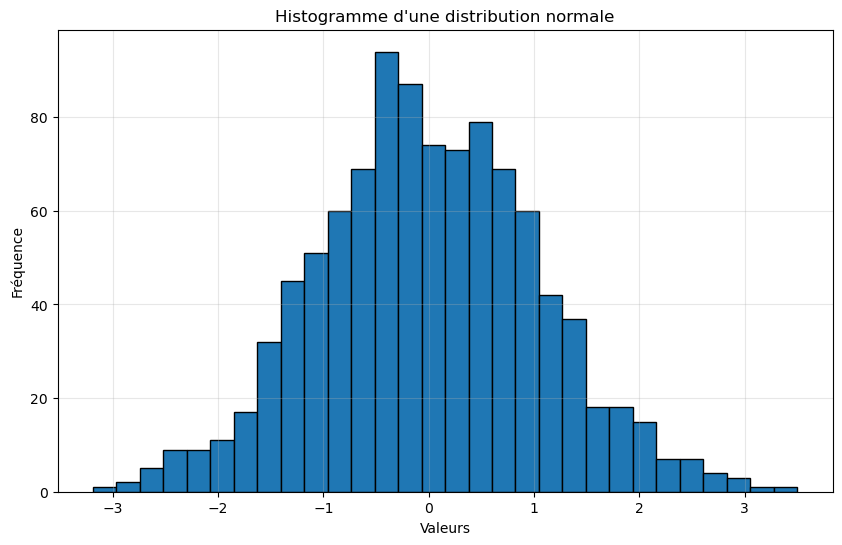

In [24]:
import random
random.seed(42)
data = np.random.normal(loc=0, scale=1, size=1000)

plt.figure(figsize=(10, 6))
plt.hist(data, bins=30, edgecolor='black')
plt.title("Histogramme d'une distribution normale")
plt.xlabel("Valeurs")
plt.ylabel("Fréquence")
plt.grid(alpha=0.3)

skewness = np.mean(((data - data.mean()) / data.std(ddof=0)) ** 3)
kurtosis = np.mean(((data - data.mean()) / data.std(ddof=0)) ** 4) - 3

print(f"Asymétrie (skewness) : {round(skewness,2)}")
print(f"Aplatissement (kurtosis excess) : {round(kurtosis,2)}")
print("Interprétation :")
print(" - Une asymétrie proche de 0 indique une distribution approximativement symétrique.")
print(" - Un aplatissement proche de 0 indique une forme proche de la distribution normale standard.")

## **Exercice 3**

In [25]:
# Generating monthly sales data as a NumPy array
monthly_sales_data = np.random.randint(100, 500, size=12)  # Random sales data for 12 months

In [26]:
monthly_sales_data

array([193, 184, 308, 138, 144, 119, 175, 475, 442, 129, 303, 463])

In [27]:
month = ["Jan", "Fev", "Mars", "Avril", "Mai","Juin","Juillet", "Août","Sept","Oct","Nov","Dec"]

In [28]:
import pandas as pd

In [43]:
df = pd.DataFrame(
    {'Sales' : monthly_sales_data,
    'Month' : month
    }
)

In [44]:
df.head()

,Sales,Month
0,193,Jan
1,184,Fev
2,308,Mars
3,138,Avril
4,144,Mai


In [40]:
df.head()

,Sales
0,193
1,184
2,308
3,138
4,144


La régression linéaire est un algorithme de machine très puissant pour la prédiction d'évement, il se base sur des données quantitatif et projette les coordonnées dans un repère ou il va se servire de sa sa droite de régression pour minimiser l'erreur (ici les ventes)

## **Exercice 4**

In [45]:
import pandas as pd

# Creating a sample Pandas DataFrame
data = {
    'Product': ['Product A', 'Product B', 'Product C', 'Product A', 'Product B'],
    'Sales': [200, 150, 300, 250, 180],
    'Month': ['January', 'February', 'March', 'April', 'May']
}
df = pd.DataFrame(data)

# 1) Agrégations classiques par groupe
agg_simple = df.groupby('Product')['Sales'].agg(['sum', 'mean', 'max', 'min', 'count']).reset_index()
print("Agrégation simple par produit:")
print(agg_simple, end="\n\n")

# 2) Agrégation nommée (Named aggregation)
agg_named = df.groupby('Product').agg(
    total_sales=('Sales', 'sum'),
    avg_sales=('Sales', 'mean'),
    orders=('Sales', 'count')
).reset_index()
print("Agrégation nommée:")
print(agg_named, end="\n\n")

# 3) Pivot table (vue pivot)
pivot = pd.pivot_table(df, index='Product', values='Sales', aggfunc=['sum', 'mean'])
print("Pivot table:")
print(pivot, end="\n\n")

# 4) Transformation : pourcentages par rapport au total
df['pct_of_total'] = df['Sales'] / df['Sales'].sum()
print("DataFrame avec pourcentage du total des ventes:")
print(df, end="\n\n")

# 5) Transformation par groupe : moyenne et somme cumulée (transform + cumsum)
df['product_mean'] = df.groupby('Product')['Sales'].transform('mean')
df['cum_sales_by_product'] = df.groupby('Product')['Sales'].cumsum()
print("DataFrame avec moyenne par produit et cumul des ventes par produit:")
print(df, end="\n\n")

# 6) Exemple multi-index groupby (Product + Month)
multi = df.groupby(['Product', 'Month'])['Sales'].sum().sort_values(ascending=False).reset_index()
print("Somme des ventes par produit et mois:")
print(multi)

Agrégation simple par produit:
     Product  sum   mean  max  min  count
0  Product A  450  225.0  250  200      2
1  Product B  330  165.0  180  150      2
2  Product C  300  300.0  300  300      1

Agrégation nommée:
     Product  total_sales  avg_sales  orders
0  Product A          450      225.0       2
1  Product B          330      165.0       2
2  Product C          300      300.0       1

Pivot table:
            sum   mean
          Sales  Sales
Product               
Product A   450  225.0
Product B   330  165.0
Product C   300  300.0

DataFrame avec pourcentage du total des ventes:
     Product  Sales     Month  pct_of_total
0  Product A    200   January      0.185185
1  Product B    150  February      0.138889
2  Product C    300     March      0.277778
3  Product A    250     April      0.231481
4  Product B    180       May      0.166667

DataFrame avec moyenne par produit et cumul des ventes par produit:
     Product  Sales     Month  pct_of_total  product_mean  \
0  Pro

## **Exercice 5**

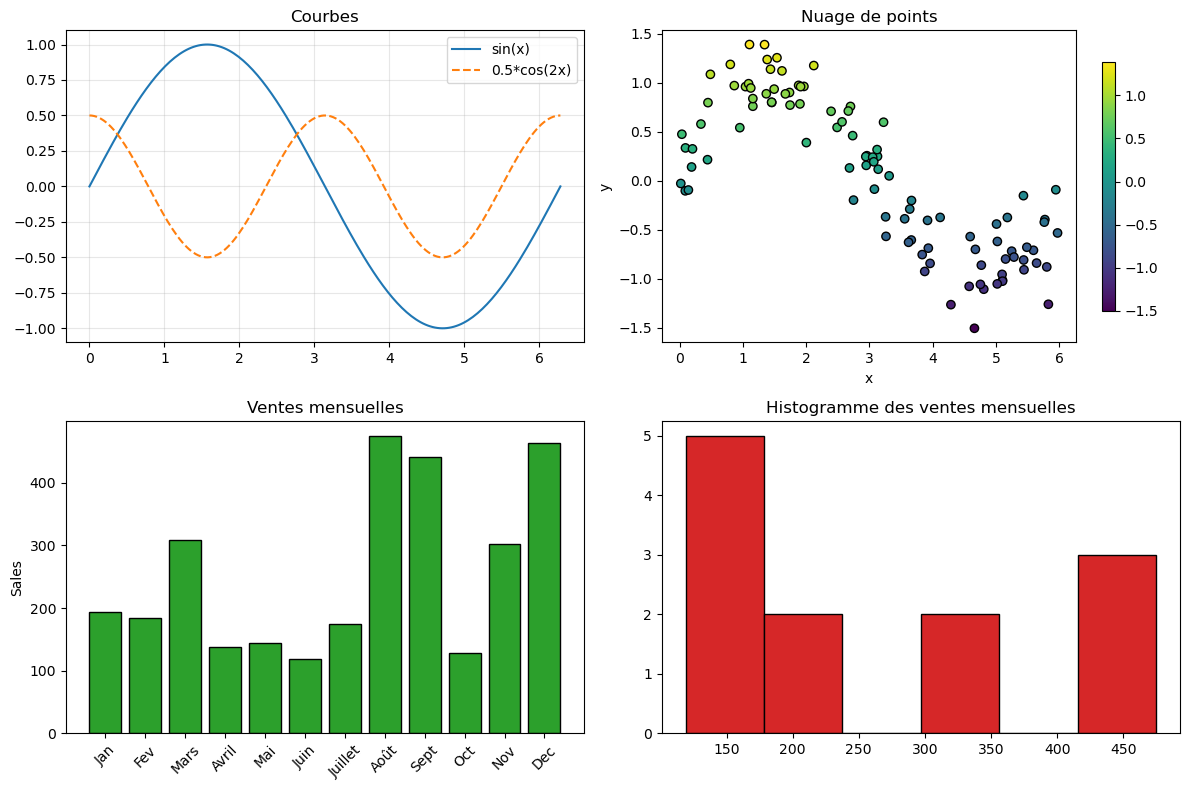

In [46]:
import matplotlib.pyplot as plt

# Line data
x = np.linspace(0, 2 * np.pi, 200)
y1 = np.sin(x)
y2 = 0.5 * np.cos(2 * x)

# Scatter data
rng = np.random.default_rng(123)
sx = rng.uniform(0, 2 * np.pi, 100)
sy = np.sin(sx) + 0.3 * rng.normal(size=100)

# Bar data (use existing variables)
labels = month
heights = monthly_sales_data

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Line plot
ax = axes[0, 0]
ax.plot(x, y1, label='sin(x)')
ax.plot(x, y2, label='0.5*cos(2x)', linestyle='--')
ax.set_title('Courbes')
ax.legend()
ax.grid(alpha=0.3)

# Scatter plot
ax = axes[0, 1]
sc = ax.scatter(sx, sy, c=sy, cmap='viridis', edgecolor='k')
ax.set_title('Nuage de points')
ax.set_xlabel('x')
ax.set_ylabel('y')
fig.colorbar(sc, ax=ax, shrink=0.8)

# Bar plot
ax = axes[1, 0]
ax.bar(range(len(labels)), heights, color='C2', edgecolor='k')
ax.set_title('Ventes mensuelles')
ax.set_ylabel('Sales')
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45)

# Histogram
ax = axes[1, 1]
ax.hist(heights, bins=6, color='C3', edgecolor='k')
ax.set_title("Histogramme des ventes mensuelles")

plt.tight_layout()
plt.show()